## Environment Setup & BigQuery Configuration
We load the GOOGLE_PROJECT_ID from your .env file to establish a secure connection using the BigQuery Python SDK.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
from dotenv import load_dotenv
from google.cloud import bigquery

warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load environment variables
load_dotenv()
PROJECT_ID = os.getenv('GOOGLE_PROJECT_ID')

# Initialize BigQuery client (using OAuth)
client = bigquery.Client(project=PROJECT_ID)
DATASET = "olist"

print(f"Connected to project: {PROJECT_ID}, dataset: {DATASET}")

Connected to project: zwxpjt1, dataset: olist


## Data Loading & Initial Shape Analysis
We fetch the critical tables into DataFrames to begin the EDA process.

In [6]:
# =============================================================================
# 1. DATA LOADING AND INITIAL EXPLORATION
# =============================================================================

def load_table(table_name):
    query = f"SELECT * FROM `{PROJECT_ID}.{DATASET}.{table_name}`"
    return client.query(query).to_dataframe()

# Loading core tables
df_dim_customers = load_table('dim_customers')
df_dim_products = load_table('dim_products')
df_fct_sales = load_table('fct_sales')
df_int_orders_enriched = load_table('int_orders_enriched')
df_int_metrics = load_table('int_customer_metrics')
df_int_items_aggr = load_table('int_order_items_aggregated')

# Print shapes for initial audit
tables = {
    "dim_customers": df_dim_customers,
    "dim_products": df_dim_products,
    "fct_sales": df_fct_sales,
    "int_orders_enriched": df_int_orders_enriched,
    "int_metrics": df_int_metrics,
    "int_items_aggr": df_int_items_aggr
}

for name, df in tables.items():
    print(f"Table: {name:20} | Rows: {df.shape[0]:<7} | Columns: {df.shape[1]}")


Table: dim_customers        | Rows: 96096   | Columns: 15
Table: dim_products         | Rows: 32951   | Columns: 12
Table: fct_sales            | Rows: 113419  | Columns: 12
Table: int_orders_enriched  | Rows: 99441   | Columns: 29
Table: int_metrics          | Rows: 94698   | Columns: 4
Table: int_items_aggr       | Rows: 98666   | Columns: 4


## Statistical Profiling & Distribution Curves
Using .describe() to identify numerical anomalies and long-tail distributions in sales metrics.

--- FCT_SALES Metrics ---


,price,freight_value,total_payment_value
count,113419.000000,113419.000000,113419.000000
mean,121.268048,19.854707,141.148161
std,185.555920,15.838002,191.917384
min,0.850000,0.000000,9.340000
25%,39.900000,12.960000,55.790000
50%,75.000000,16.220000,92.650000
75%,135.000000,21.150000,158.100000
max,6735.000000,409.680000,6929.310000


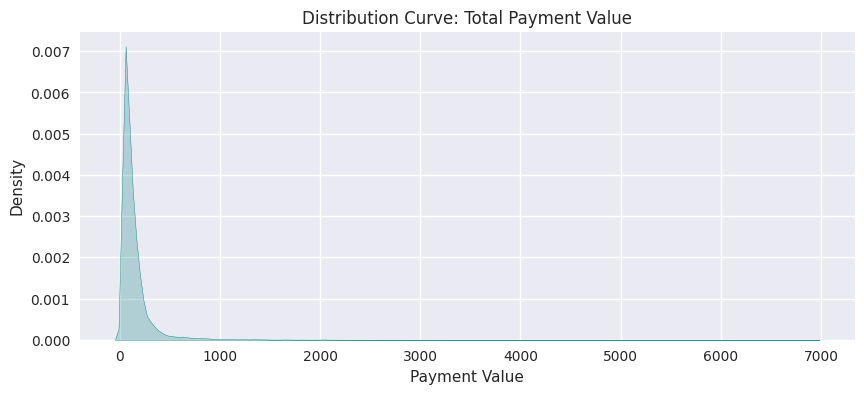

In [8]:
# =============================================================================
# 2. STATISTICAL PROFILING
# =============================================================================

# --- FIX: Convert to Float for math/plotting ---
cols_to_fix = ['price', 'freight_value', 'total_payment_value']
df_fct_sales[cols_to_fix] = df_fct_sales[cols_to_fix].astype(float)

print("--- FCT_SALES Metrics ---")
# Now this will show Mean, Std, Min, Max instead of 'Unique/Top'
display(df_fct_sales[cols_to_fix].describe())

# Visualizing the curve for Sales Value
plt.figure(figsize=(10, 4))
sns.kdeplot(df_fct_sales['total_payment_value'], fill=True, color='teal')
plt.title('Distribution Curve: Total Payment Value')
plt.xlabel('Payment Value')
plt.show()


## Dim_Customers Logic Check & Order Status Filtering
Filtering out 'canceled' or 'unavailable' orders from the enriched table to explain null RFV scores in the customer dimension.

In [9]:
# =============================================================================
# 3. CUSTOMER DIMENSION & ENRICHED STATUS CHECK
# =============================================================================

# Filter orders to exclude canceled/unavailable
valid_orders = df_int_orders_enriched[~df_int_orders_enriched['order_status'].isin(['canceled', 'unavailable'])]

# Checking the null RFV records mentioned (e.g., 01012, 01019)
invalid_customers = df_dim_customers[df_dim_customers['rfv_score'].isna()]
print(f"Customers with NULL RFV: {len(invalid_customers)}")

# Verify customer_id_is_invalid is always False
print(f"Unique values in customer_id_is_invalid: {df_dim_customers['customer_id_is_invalid'].unique()}")


Customers with NULL RFV: 0
Unique values in customer_id_is_invalid: <BooleanArray>
[False]
Length: 1, dtype: boolean


## Dim_Products & Categorization Audit
Checking for 'uncategorized' placeholders and null values in physical dimensions.

In [10]:
# =============================================================================
# 4. PRODUCT VALIDATION & CATEGORY RETEST
# =============================================================================

# Retest uncategoried products
uncategorized = df_dim_products[df_dim_products['product_category_name'].isin(['', 'uncategorized'])]
print(f"Uncategorized Products count: {len(uncategorized)}")

# Checking for null weights/dimensions
null_specs = df_dim_products[['product_weight_g', 'product_length_cm']].isna().sum()
print("Missing Product Specifications:\n", null_specs)


Uncategorized Products count: 591
Missing Product Specifications:
 product_weight_g     0
product_length_cm    0
dtype: int64


## Intermediate Table Patching & Monetary Logic
Implementing logic to fill monetary_value from order_payments when order item data is missing.

In [12]:
# =============================================================================
# 5. METRICS & MONETARY VALUE CORRECTION
# =============================================================================

# --- Fix 1: Monetary Value (df_int_metrics) ---
# We convert to float first just in case, then fill nulls with 0
df_int_metrics['monetary_value'] = df_int_metrics['monetary_value'].astype(float).fillna(0)

# Verify the fix
null_monetary = df_int_metrics['monetary_value'].isna().sum()
print(f"5. Null Monetary Values remaining: {null_monetary} (Expected: 0)")


# --- Fix 2: Rounding (df_int_items_aggr) ---
df_int_items_aggr = load_table('int_order_items_aggregated')

# We MUST convert to float before rounding to avoid the "Object" error
df_int_items_aggr['total_item_value'] = df_int_items_aggr['total_item_value'].astype(float).round(2)
df_int_items_aggr['total_freight_value'] = df_int_items_aggr['total_freight_value'].astype(float).round(2)

print("Rounded long decimals for Item Aggregation table.")
display(df_int_items_aggr.tail(1))


5. Null Monetary Values remaining: 0 (Expected: 0)
Rounded long decimals for Item Aggregation table.


,order_id,total_item_value,total_freight_value,total_items
98665,b4546ff451b39382f5c1dd81355a0c58,238.99,22.47,1


## City & State Normalization Check
Verifying that all geographic data is standardized by ensuring no accents remain in city or state names.

In [17]:
# =============================================================================
# 6. ACCENT & NORMALIZATION AUDIT
# =============================================================================

import re

def has_accents(text):
    if text is None: return False
    # Checks for characters outside standard A-Z, 0-9, and basic punctuation
    return bool(re.search(r'[^\x00-\x7F]+', str(text)))

# 1. Check Cities
accented_cities = df_dim_customers[df_dim_customers['customer_city'].apply(has_accents)]

# 2. Check States
accented_states = df_dim_customers[df_dim_customers['customer_state'].apply(has_accents)]

print(f"--- Accent Check Results ---")
print(f"Cities with remaining accents: {len(accented_cities)}")
print(f"States with remaining accents: {len(accented_states)}")

if len(accented_cities) > 0:
    print("\nSample of accented cities found:")
    display(accented_cities[['customer_id', 'customer_city']].head(5))
else:
    print("\n✅ All cities are successfully normalized (Accents removed).")

# Show the 10 problematic cities
display(accented_cities[['customer_id', 'customer_city', 'customer_state']])


--- Accent Check Results ---
Cities with remaining accents: 10
States with remaining accents: 0

Sample of accented cities found:


,customer_id,customer_city
70233,ebf83d791ff75483ab26bc06ab002e32,maceia³
70234,79014ee04085d90c94cb55b6042e4bb7,maceia³
70235,41cdb26d1a0145f92b2fa8ea92b9cd0b,maceia³
70236,af8d07e04415b17eec6472d8f31e83ed,maceia³
70237,bfdb1f4f667634b7ff30a716e6fafa95,maceia³


,customer_id,customer_city,customer_state
70233,ebf83d791ff75483ab26bc06ab002e32,maceia³,AL
70234,79014ee04085d90c94cb55b6042e4bb7,maceia³,AL
70235,41cdb26d1a0145f92b2fa8ea92b9cd0b,maceia³,AL
70236,af8d07e04415b17eec6472d8f31e83ed,maceia³,AL
70237,bfdb1f4f667634b7ff30a716e6fafa95,maceia³,AL
70238,2c8deb31537465309060d5176e5da3d3,maceia³,AL
70239,bf82837a50afe7e09679eeedfa1285ce,maceia³,AL
70240,99a6c03de00a86b302d05d0eedd6e0e0,maceia³,AL
70241,55358388564c39b1d171621395ea2544,maceia³,AL
70242,0d3670b39e22cd5272b0cee0bcbfd600,maceia³,AL


## Final Sales & Payments Integrity
Removing records where payment methods or total payments are zero to ensure fct_sales purity.

In [13]:
# =============================================================================
# 6. FINAL INTEGRITY CHECKS (FCT_SALES)
# =============================================================================

df_payments_summary = load_table('int_order_payments_summary')

# Identify zero-payment orders to remove from Fact table
invalid_payment_ids = df_payments_summary[
    (df_payments_summary['unique_payment_methods'] == 0) | 
    (df_payments_summary['total_order_payment'] == 0)
]['order_id']

df_fct_sales_cleaned = df_fct_sales[~df_fct_sales['order_id'].isin(invalid_payment_ids)]

diff = len(df_fct_sales) - len(df_fct_sales_cleaned)
print(f"Actual rows dropped from fct_sales: {diff}")

print(df_fct_sales_cleaned.shape)

print(df_fct_sales_cleaned.info())

Actual rows dropped from fct_sales: 0
(113419, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113419 entries, 0 to 113418
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   sale_id               113419 non-null  object 
 1   order_id              113419 non-null  object 
 2   customer_id           113419 non-null  object 
 3   product_id            113419 non-null  object 
 4   seller_id             113419 non-null  object 
 5   location_id           113419 non-null  object 
 6   time_id               113419 non-null  dbdate 
 7   quantity              113419 non-null  object 
 8   price                 113419 non-null  float64
 9   freight_value         113419 non-null  float64
 10  total_payment_value   113419 non-null  float64
 11  payment_installments  113419 non-null  Int64  
dtypes: Int64(1), dbdate(1), float64(3), object(7)
memory usage: 10.5+ MB
None
